### Завантаження та огляд датасету

#### - завантажуємо набір даних

In [2]:
import pandas as pd

df = pd.read_csv('Coffe_sales.csv')

#### - перевіряємо розмір датасету, виводимо перші 5 рядків, робимо огляд назв колонок і типів даних

In [3]:
display(df.shape)
display(df.head(5))
display(df.info())

(3547, 11)

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


None

#### - перевіряємо пропущені значення

In [4]:
df.isnull().sum()

hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64

#### - перевіряємо дублікати

In [5]:
df.duplicated().sum()

np.int64(0)

#### - перетворюємо дату з типу object в тип datetime64[ns]

In [6]:
df["Date"] = pd.to_datetime(df["Date"])

In [7]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   hour_of_day  3547 non-null   int64         
 1   cash_type    3547 non-null   object        
 2   money        3547 non-null   float64       
 3   coffee_name  3547 non-null   object        
 4   Time_of_Day  3547 non-null   object        
 5   Weekday      3547 non-null   object        
 6   Month_name   3547 non-null   object        
 7   Weekdaysort  3547 non-null   int64         
 8   Monthsort    3547 non-null   int64         
 9   Date         3547 non-null   datetime64[ns]
 10  Time         3547 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(6)
memory usage: 304.9+ KB


None

#### - перевіряємо унікальні значення категоріальних колонок

In [8]:
categorical_columns = [column for column in df.select_dtypes(include=["object"]).columns if column != "Time"]


for column in categorical_columns:
    print(df[column].value_counts(dropna=False))

cash_type
card    3547
Name: count, dtype: int64
coffee_name
Americano with Milk    809
Latte                  757
Americano              564
Cappuccino             486
Cortado                287
Hot Chocolate          276
Cocoa                  239
Espresso               129
Name: count, dtype: int64
Time_of_Day
Afternoon    1205
Morning      1181
Night        1161
Name: count, dtype: int64
Weekday
Tue    572
Mon    544
Fri    532
Thu    510
Wed    500
Sat    470
Sun    419
Name: count, dtype: int64
Month_name
Mar    494
Oct    426
Feb    423
Sep    344
Aug    272
Nov    259
Dec    259
May    241
Jul    237
Jun    223
Jan    201
Apr    168
Name: count, dtype: int64


*Всі значення категоріальних колонок унікальні*

#### - перевіряємо викиди

In [9]:
df.describe()

,hour_of_day,money,Weekdaysort,Monthsort,Date
count,3547.000000,3547.000000,3547.000000,3547.000000,3547
mean,14.185791,31.645216,3.845785,6.453905,2024-10-04 17:34:43.676346368
min,6.000000,18.120000,1.000000,1.000000,2024-03-01 00:00:00
25%,10.000000,27.920000,2.000000,3.000000,2024-07-17 12:00:00
50%,14.000000,32.820000,4.000000,7.000000,2024-10-10 00:00:00
75%,18.000000,35.760000,6.000000,10.000000,2025-01-11 00:00:00
max,22.000000,38.700000,7.000000,12.000000,2025-03-23 00:00:00
std,4.234010,4.877754,1.971501,3.500754,NaN


*Дуже малих чи великих значень немає, отже, викиди відсутні*

### Аналітичні питання, відповіді на них та рекомендації для бізнесу

**1. Який середній чек клієнтів та як розподіляються суми транзакцій?**

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

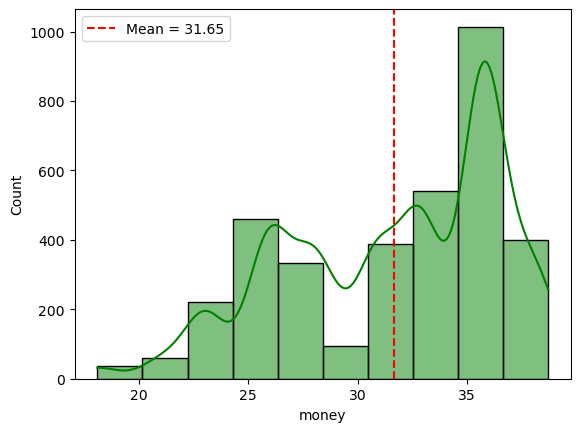

In [15]:
avg_sum_tx = df["money"].mean()

sns.histplot(data=df, x="money", bins=10, kde=True, color='green')

plt.axvline(avg_sum_tx, color="red", linestyle="--", label=f"Mean = {avg_sum_tx:.2f}")

plt.legend()
plt.show()

**Відповідь:** середній чек становить приблизно 31.65. Найбільша кількість транзакцій припадає на діапазон 35–36, що свідчить про популярність покупок у цьому ціновому сегменті. Значних аномалій або екстремальних платежів не виявлено.

**Рекомендації для бізнесу:** оскільки найбільше покупок припадає на суму 35–36, варто робити основні акції та пропозиції саме в цьому діапазоні — це той рівень витрат, який клієнти найчастіше обирають і до якого вони вже звикли; щоб підвищити середній чек (31.65), можна заохочувати клієнтів витрачати більше: пропонувати додаткові товари до покупки, створювати вигідні набори або давати бонуси/знижки при досягненні певної суми замовлення. Це допоможе збільшити загальну суму кожної покупки.

**2. Які види кави формують основну частину продажів?**

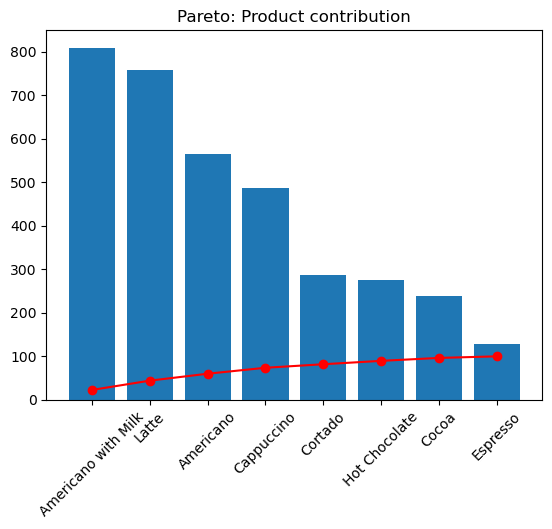

In [16]:
top_coffee = df["coffee_name"].value_counts().head(10)

cum_percent = top_coffee.cumsum() / top_coffee.sum() * 100

plt.bar(top_coffee.index, top_coffee.values)
plt.plot(top_coffee.index, cum_percent, color="red", marker="o")

plt.xticks(rotation=45)
plt.title("Pareto: Product contribution")
plt.show()

**Відповідь:** аналіз показує, що найбільший внесок у продажі роблять такі види кави, як Americano with Milk, Latte, Americano, Cappuccino. Саме ці продукти формують основну частину загального обсягу продажів. Натомість Cortado, Espresso, Cocoa та Hot Chocolate мають значно нижчий внесок. Це означає, що бізнес сильно залежить від кількох ключових продуктів — принцип Парето (80/20), коли невелика кількість товарів приносить основну частину результату.

**Рекомендації для бізнесу:** активніше просувати Latte, Americano with Milk, Americano, використовуючи акції, комбо-набори, рекламу, програми лояльності. За рахунок популярних напоїв можна збільшити середній чек, пропонуючи більший розмір, додаткові сиропи, десерти, сезонні доповнення. Для популярних напоїв важливо підтримувати стабільні запаси інгредієнтів, уникати дефіциту, прогнозувати попит. Для слабких позицій (Cortado, Espresso, Cocoa та Hot Chocolate) можна спробувати знизити ціну, оновити їхню рецептуру, пропонувати безкоштовний смаколик до них. 

**3. В які години найбільше купують каву?**

In [19]:
hourly_sales = df.groupby('hour_of_day')['money'].sum().reset_index()
hourly_sales

,hour_of_day,money
0,6,149.40
1,7,2846.02
2,8,7017.88
3,9,7264.28
4,10,10198.52
5,11,8453.10
6,12,7419.62
7,13,7028.76
8,14,7173.80
9,15,7476.02


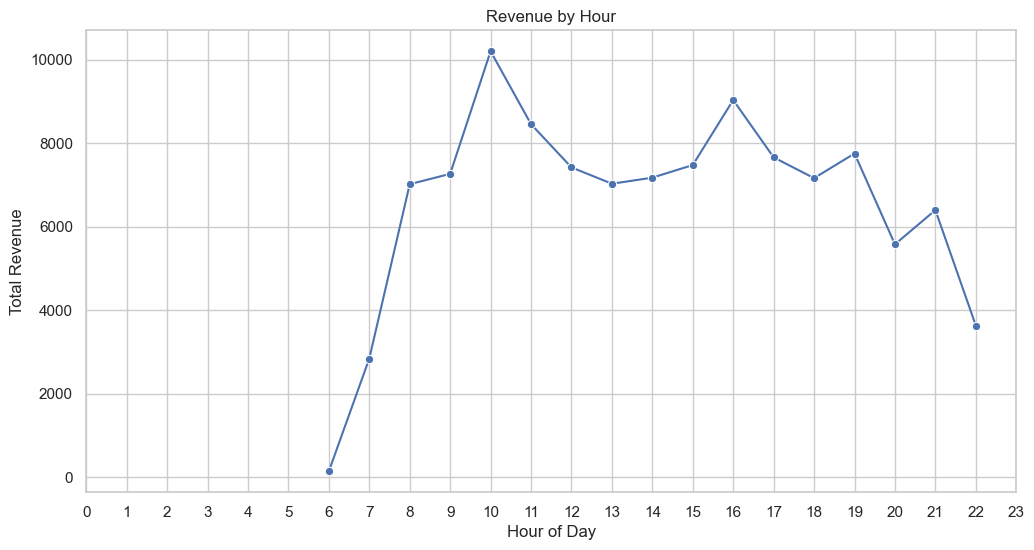

In [20]:
hourly_sales = df.groupby('hour_of_day')['money'].sum().reset_index()

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,6))

sns.lineplot(
    data=hourly_sales,
    x='hour_of_day',
    y='money',
    marker='o'
)

plt.title('Revenue by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Total Revenue')

plt.xticks(range(0,24))

plt.show()

**Відповідь:** найнижчий дохід спостерігається о 06:00–07:00. Після 07:00 дохід різко зростає. Найвищий пік продажів припадає на 10:00 — це найприбутковіша година. Високий рівень доходу також спостерігається з 11:00 до 17:00; окремий вечірній пік — близько 16:00. Після 19:00 дохід починає знижуватися. Найбільше падіння видно після 21:00–22:00. Отже, основний потік клієнтів припадає на ранковий та денний час. Найбільш активний період — перед обідом. Вечірній попит існує, але поступово зменшується ближче до закриття.

**Рекомендації для бізнесу:** у проміжку 08:00–11:00 і 15:00–17:00 варто збільшити кількість барист, прискорити обслуговування, підготувати популярні інгредієнти заздалегідь. Треба максимізувати прибуток у години піку. Оскільки 10:00 — найприбутковіша година, у цей час можна пропонувати до кави десерт, рекомендувати великі порції, просувати сезонні напої. Для 06:00–07:00 можна робити знижки “ранкова кава”, запускати акції до 8 ранку, пропонувати швидкі сніданки. Після 19:00 попит падає, тому для підвищення активності в цей час можна запускати вечірні пропозиції, робити акції на десерти, вводити щасливі години.

**4. Як змінюється дохід кав’ярні залежно від часу дня та в який період продажі є найстабільнішими й найприбутковішими?**

In [21]:
time_of_day_sales = df.groupby('Time_of_Day')['money'].sum().reset_index()
time_of_day_sales

,Time_of_Day,money
0,Afternoon,38130.04
1,Morning,35929.20
2,Night,38186.34


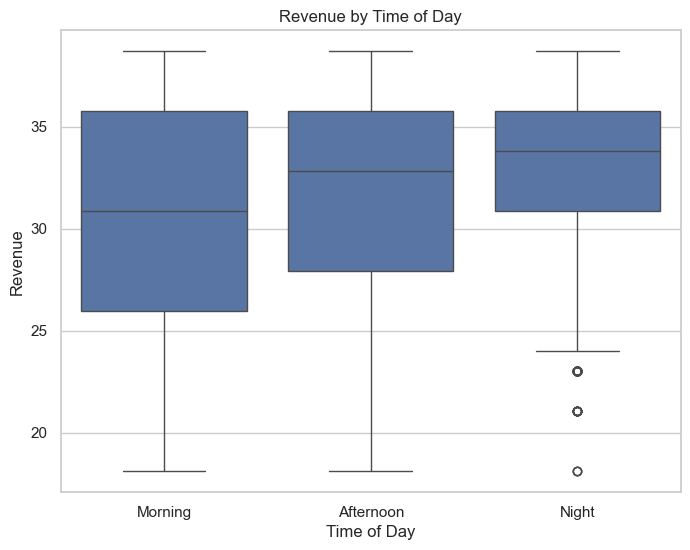

In [22]:
time_of_day_sales = df.groupby('Time_of_Day')['money'].sum().reset_index()

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='Time_of_Day',
    y='money'
)

plt.title('Revenue by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Revenue')

plt.show()

**Відповідь:** вночі кав'ярня має найвищу медіану доходу, тобто у нічний час середній дохід з продажів є найбільшим. У ранковий час розкид значень більший, отже, вранці дохід менш стабільний: бувають як високі, так і середні продажі. В обід розподіл доходу більш рівномірний. У нічний час є кілька аномально низьких значень, тобто окремі періоди з дуже слабкими продажами. 

**Рекомендації для бізнесу:** Для ранку - збільшити кількість персоналу у години пікового навантаження, запровадити ранкові знижки, оптимізувати швидкість обслуговування, оскільки клієнти часто поспішають. Для дня - використовувати цей стабільний період для пропозиції купити разом з кавою десерти або солоні снеки, продажу великих розмірів напоїв. Можна запустити програму лояльності для офісних працівників або студентів.
Для ночі - просувати преміальні або дорожчі позиції меню. Також треба проаналізувати причини низьких викидів вночі (це через погоду, недостатній потік людей, неефективний графік роботи). Якщо нічні продажі часто падають — можна скоротити години роботи або запускати нічні акції.

**5. У які дні тижня середній дохід від кави найбільший?**

In [24]:
weekday_sales = df.groupby('Weekday')['money'].mean().reset_index()
weekday_sales

,Weekday,money
0,Fri,31.583947
1,Mon,31.917463
2,Sat,31.347915
3,Sun,31.828305
4,Thu,31.551765
5,Tue,31.762902
6,Wed,31.500920


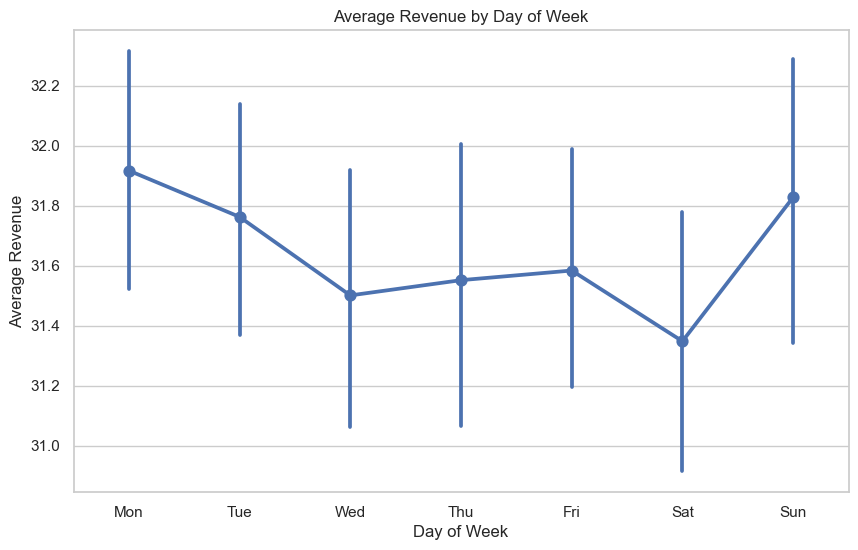

In [25]:
weekday_sales = df.groupby('Weekday')['money'].mean().reset_index()

order = ['Mon', 'Tue', 'Wed',
         'Thu', 'Fri', 'Sat', 'Sun']

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

sns.pointplot(
    data=df,
    x='Weekday',
    y='money',
    order=order,
    estimator='mean'
)

plt.title('Average Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Revenue')

plt.show()

**Відповідь:** графік показує, що найбільший середній дохід спостерігається у понеділок та неділю. Найнижчий середній дохід зафіксований у середу та суботу. Загалом різниця між днями невелика, але початок і кінець тижня приносять більше доходу.

**Рекомендації для бізнесу:** у понеділок варто збільшити кількість персоналу та запасів, оскільки попит вищий після вихідних. У неділю треба активно просувати десерти, сезонні напої та сімейні комбо-пропозиції. У середу та суботу варто запустити акції або програми лояльності для стимулювання продажів. Аналізувати причини слабших продажів у середині тижня та у суботу, щоб оптимізувати маркетингові кампанії.

**6. Яку динаміку середнього доходу показує кав'ярня щомісячно?**

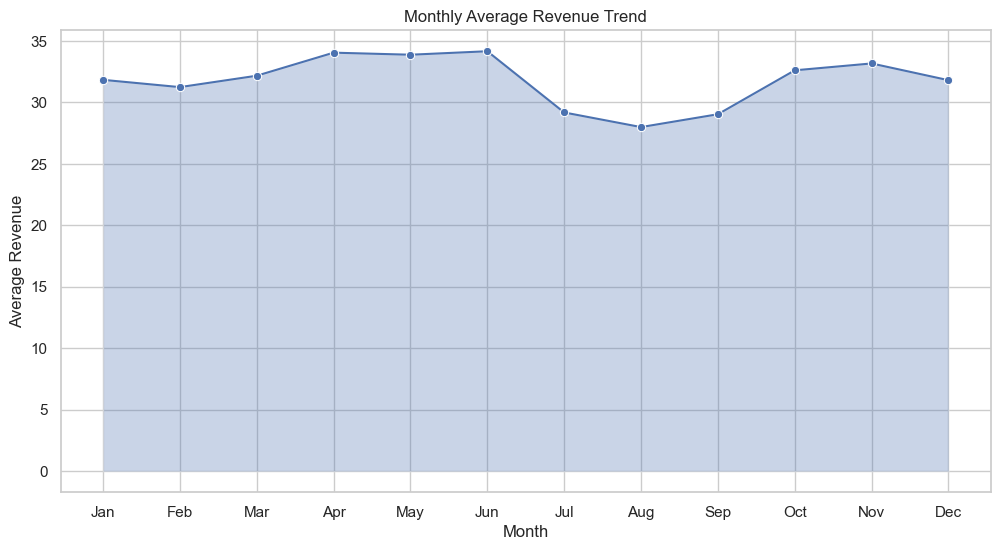

In [26]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr',
               'May', 'Jun', 'Jul', 'Aug',
               'Sep', 'Oct', 'Nov', 'Dec']

monthly_revenue = (
    df.groupby('Month_name')['money']
    .mean()
    .reindex(month_order)
    .reset_index()
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_revenue,
    x='Month_name',
    y='money',
    marker='o'
)

plt.fill_between(
    monthly_revenue['Month_name'],
    monthly_revenue['money'],
    alpha=0.3
)

plt.title('Monthly Average Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Average Revenue')

plt.show()

In [27]:
monthly_revenue

,Month_name,money
0,Jan,31.835124
1,Feb,31.242270
2,Mar,32.169312
3,Apr,34.045000
4,May,33.877261
5,Jun,34.160359
6,Jul,29.181181
7,Aug,27.992059
8,Sep,29.036744
9,Oct,32.608357


**Відповідь:** графік показує, що середній дохід кав’ярні змінюється нерівномірно протягом року. Найвищий середній дохід спостерігається у квітні, травні, червні. Після цього влітку відбувається помітний спад (найнижчі значення зафіксовані у липні та серпні). Восени дохід знову починає зростати (особливо у жовтні та листопаді). Наприкінці року спостерігається невелике зниження. Загалом графік свідчить про наявність сезонності у продажах кав’ярні.

**Рекомендації для бізнесу:** навесні треба збільшити запаси та кількість персоналу через високий попит; влітку - запускати холодні напої, сезонні меню та акції для підтримки продажів; восени - активніше просувати гарячі напої та десерти, оскільки попит зростає; наприкінці року - використовувати святкові пропозиції та комбо-набори для утримання доходу.

**7. У якому кварталі кав’ярня отримує найвищий та найстабільніший дохід?**

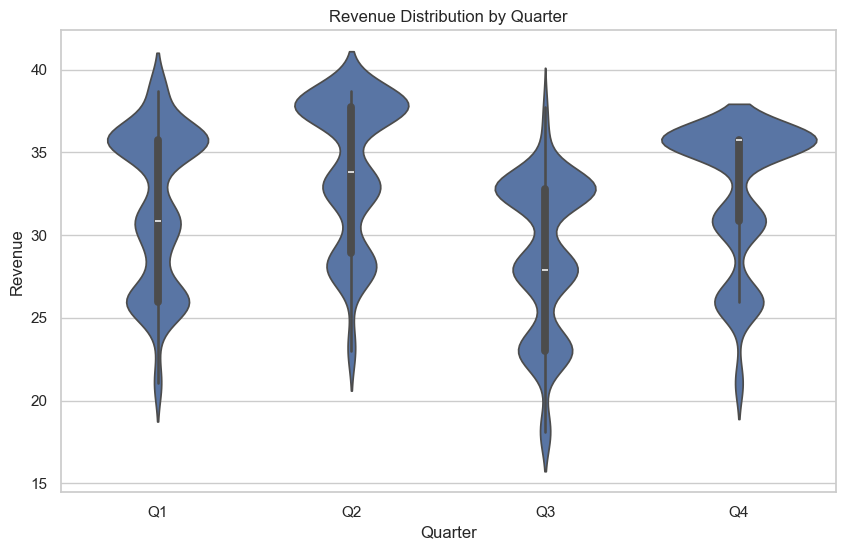

In [28]:
quarter_map = {
    'Jan': 'Q1', 'Feb': 'Q1', 'Mar': 'Q1',
    'Apr': 'Q2', 'May': 'Q2', 'Jun': 'Q2',
    'Jul': 'Q3', 'Aug': 'Q3', 'Sep': 'Q3',
    'Oct': 'Q4', 'Nov': 'Q4', 'Dec': 'Q4'
}

df['quarter'] = df['Month_name'].map(quarter_map)

quarter_order = ['Q1', 'Q2', 'Q3', 'Q4']

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='quarter',
    y='money',
    order=quarter_order
)

plt.title('Revenue Distribution by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Revenue')

plt.show()

**Відповідь:** графік показує, що другий квартал має найвищі значення доходу — саме у другому кварталі кав’ярня працює найприбутковіше. Третій квартал демонструє найнижчий рівень доходу та більшу кількість низьких значень доходу. Четвертий квартал характеризується стабільними та відносно високими продажами. У першому кварталі дохід є середнім, але менш стабільним, ніж у четвертому. Загалом можна побачити сезонність: навесні та восени продажі вищі, а влітку — нижчі.

**Рекомендації для бізнесу:** для другого кварталу - збільшити запаси, персонал та маркетингову активність, щоб максимально використати високий попит. Третій квартал - запускати літні акції, холодні напої та сезонні пропозиції для підтримки доходу. Четвертий квартал - активно просувати святкові меню та комбо-пропозиції. Аналізувати фактори сезонності для кращого планування продажів і закупівель.

**8. Які фактори найбільше впливають на дохід кав’ярні та чи існує сезонність у продажах?**

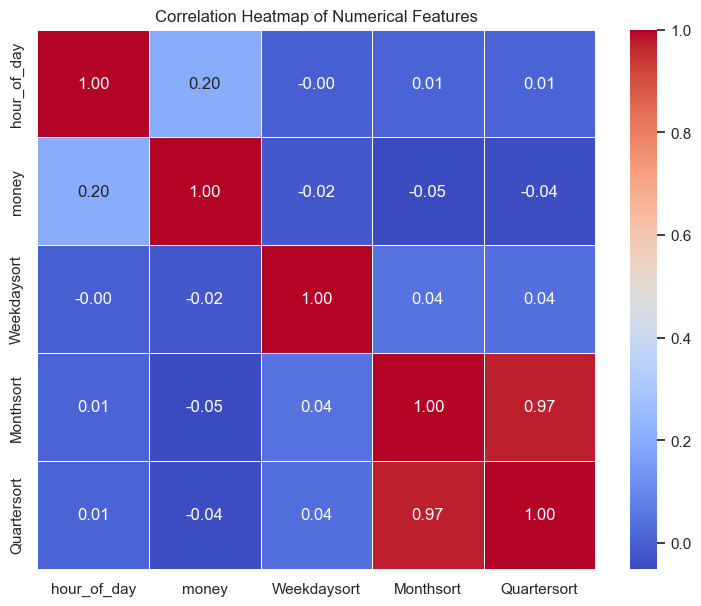

In [29]:
quarter_map = {
    'Jan': 1, 'Feb': 1, 'Mar': 1,
    'Apr': 2, 'May': 2, 'Jun': 2,
    'Jul': 3, 'Aug': 3, 'Sep': 3,
    'Oct': 4, 'Nov': 4, 'Dec': 4
}

df['Quartersort'] = df['Month_name'].map(quarter_map)

numeric_cols = [
    'hour_of_day',
    'money',
    'Weekdaysort',
    'Monthsort',
    'Quartersort'
]

corr_matrix = df[numeric_cols].corr()

sns.set_theme(style="white")

plt.figure(figsize=(9,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Features')

plt.show()


**Відповідь:** кореляційна heatmap показує, що hour_of_day має слабку позитивну кореляцію з money (0.20). Це означає, що час покупки частково впливає на дохід; у певні години клієнти витрачають більше. Weekdaysort, Monthsort та Quartersort мають дуже слабкий зв’язок із доходом. Сезонність та день тижня впливають на дохід незначно. Отже, основний вплив на продажі має саме час покупки.

**Рекомендації для бізнесу:** зосередити маркетинг та персонал на пікових годинах продажів, аналізувати години з найбільшим доходом для запуску преміальних пропозицій, не покладатися лише на сезонність при плануванні продажів, оскільки її вплив слабкий, використовувати часові патерни для оптимізації графіка роботи та запасів продукції.

**9. Чи відрізняється середній дохід кав’ярні у будні та вихідні дні?**

A/B групи:

Group A — Weekdays (Monday–Friday)

Group B — Weekends (Saturday–Sunday).

Гіпотези:

H₀ - середній дохід у будні та вихідні однаковий

H₁ - середній дохід у будні та вихідні відрізняється.

In [30]:
from scipy.stats import ttest_ind

weekdays = df[df['Weekday'].isin([
    'Mon', 'Tue', 'Wed',
    'Thu', 'Fri'
])]['money']

weekends = df[df['Weekday'].isin([
    'Sat', 'Sun'
])]['money']

t_stat, p_value = ttest_ind(
    weekdays,
    weekends,
    equal_var=False
)

print("Weekdays mean revenue:", weekdays.mean())
print("Weekends mean revenue:", weekends.mean())

print("T-statistic:", t_stat)
print("P-value:", p_value)

Weekdays mean revenue: 31.66892400300978
Weekends mean revenue: 31.57433070866142
T-statistic: 0.49578360584640024
P-value: 0.6201197197340662


**Висновок A/B тесту:** було перевірено гіпотезу про те, чи відрізняється середній дохід кав’ярні у будні та вихідні дні. Оскільки p-value = 0.620 > 0.05, немає статистично значущої різниці між середнім доходом у будні та вихідні. Тобто різниця в доході є дуже незначною і може бути випадковою. Отже, попит у кав’ярні залишається відносно стабільним протягом усього тижня. Вихідні не приносять суттєво більшого доходу порівняно з будніми. 

**10. Які фактори найбільше впливають на високий дохід від транзакцій у кав’ярні?**

Accuracy: 0.967605633802817

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       407
           1       0.96      0.96      0.96       303

    accuracy                           0.97       710
   macro avg       0.97      0.97      0.97       710
weighted avg       0.97      0.97      0.97       710



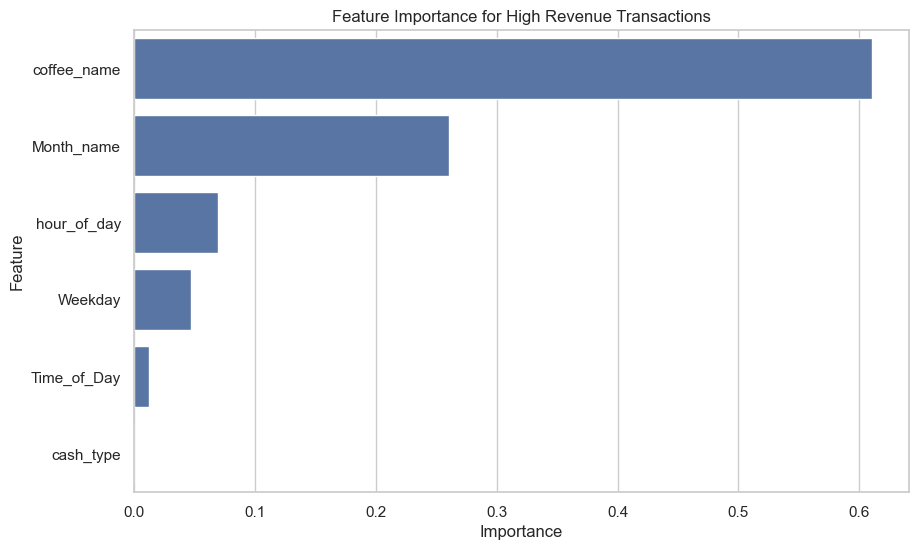

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

clf_df = df.copy()

median_revenue = clf_df['money'].median()

clf_df['high_revenue'] = (
    clf_df['money'] > median_revenue
).astype(int)

categorical_cols = [
    'cash_type',
    'coffee_name',
    'Time_of_Day',
    'Weekday',
    'Month_name'
]

le = LabelEncoder()

for col in categorical_cols:
    clf_df[col] = le.fit_transform(clf_df[col])

X = clf_df[[
    'hour_of_day',
    'cash_type',
    'coffee_name',
    'Time_of_Day',
    'Weekday',
    'Month_name'
]]

y = clf_df['high_revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance for High Revenue Transactions')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

Було використано алгоритм **Random Forest Classification** — модель supervised machine learning, яка навчилась на історичних транзакціях, автоматично знаходила закономірності, прогнозувала ймовірність high revenue transaction. Це дозволило визначити ключові фактори, що впливають на прибутковість продажів у кав’ярні.

Модель класифікувала транзакції на **high revenue і regular revenue**. Вона показала дуже високу точність (accuracy): **96.7%.** Це означає, що модель дуже добре визначає, чи матиме транзакція високий прибуток.

**Графік важливості ознак** показує, що на високий дохід:

- **coffee_name** має найбільший вплив;

- **Month_name** також суттєво впливає;

- **hour_of_day** має помірний вплив;

- **Weekday** — впливає слабше;

- **Time_of_Day** майже не впливає.

Отже, **тип напою** є головним фактором високого доходу; **сезонність** також значно впливає на дорогі покупки.

**Рекомендації для бізнесу:**

-- треба просувати найбільш прибуткові види кави через:

    - рекомендації барист;
    - комбо-набори;
    - сезонні пропозиції.

-- у місяці з високим доходом:

    - збільшувати запаси;
    - посилювати маркетингові кампанії.

-- у пікові години:

    - оптимізувати персонал;
    - просувати premium-напої.
